In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_squared_log_error
from sklearn.preprocessing import StandardScaler
from scipy import stats
from numpy.linalg import inv
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

species_name_df = pd.read_csv('/content/drive/MyDrive/Data 311 Project 3/Copy of FIATreeSpeciesCode.csv')
species_info_df = pd.read_csv('/content/drive/MyDrive/Data 311 Project 3/Copy of biomass_model_dataset.csv')

train_df = pd.read_csv('/content/drive/MyDrive/Data 311 Project 3/Copy of training_data.csv')
select_df = pd.read_csv('/content/drive/MyDrive/Data 311 Project 3/Copy of selection_data.csv')
test_df = pd.read_csv('/content/drive/MyDrive/Data 311 Project 3/Copy of testing_data.csv')
df = pd.merge(species_info_df, species_name_df.loc[:, ['SPCD', 'COMMON_NAME']], on='SPCD', how='inner')

counts = df["COMMON_NAME"].value_counts()
frequent_values = counts[counts >= 100].index
df_filter = df[df["COMMON_NAME"].isin(frequent_values)]

Mounted at /content/drive


In [ ]:
df_volume = df_filter.assign(VOLUME = (df_filter["HT_TOT"]*3.14159*(0.5*df_filter["DO_BH"])**2))
df_volume.head()

,SPCD,DO_BH,HT_TOT,TT_DW_CRM,COMMON_NAME,VOLUME
0,12,7.5,45.2,178.86,balsam fir,1996.873144
1,12,9.3,62.7,323.46,balsam fir,4259.150167
2,12,9.7,56.7,342.47,balsam fir,4190.019479
3,12,11.4,66.1,499.35,balsam fir,6746.844127
4,12,6.4,51.8,113.92,balsam fir,1666.399867


In [ ]:
rmsle = []
for i in range(len(df_volume["COMMON_NAME"].value_counts())):
    tree_name = df_volume["COMMON_NAME"].value_counts().index[i]

    #make dataframe with certain common name
    tree_subset = df_volume.loc[df_volume['COMMON_NAME'] == tree_name]

    #find last index for tarining, test, and selection index
    train_index = int(tree_subset["COMMON_NAME"].value_counts()[0] * 0.80)
    test_index = int(tree_subset["COMMON_NAME"].value_counts()[0] * 0.90)
    selection_index = int(tree_subset["COMMON_NAME"].value_counts()[0])

    #put in new dataframes
    train = pd.DataFrame(tree_subset.iloc[:train_index])
    test = pd.DataFrame(tree_subset.iloc[train_index:test_index])
    selection = pd.DataFrame(tree_subset.iloc[test_index:selection_index])

    # Split data into training and testing sets
    X_train = train[['DO_BH', 'HT_TOT', 'VOLUME']]
    y_train = train['TT_DW_CRM']
    X_test = test[['DO_BH', 'HT_TOT', 'VOLUME']]
    y_test = test['TT_DW_CRM']

    # Scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    knn_regressor = KNeighborsRegressor(n_neighbors=3)
    knn_regressor.fit(X_train_scaled, y_train)
    y_pred = knn_regressor.predict(X_test_scaled)

    rmsle.append(np.sqrt(mean_squared_log_error(y_test, y_pred))) #averages

avg_rmsle = sum(rmsle)/len(rmsle) #averages
print(f"Average Root Mean Squared Log Error (RMSLE) for k = {3}: {avg_rmsle}") #averages

Average Root Mean Squared Log Error (RMSLE) for k = 3: 0.15544459921264525


In [ ]:
X_train_conf = train[['DO_BH', 'HT_TOT', 'VOLUME']]
X_cal = selection[['DO_BH', 'HT_TOT', 'VOLUME']]
y_train_conf = train['TT_DW_CRM']
y_cal = selection['TT_DW_CRM']

k = 3
knn = KNeighborsRegressor(n_neighbors=k)
knn.fit(X_train_conf, y_train_conf)

y_pred_cal = knn.predict(X_cal)
calibration_residuals = np.abs(y_cal - y_pred_cal)
alpha = 0.05
q_conformal = np.quantile(calibration_residuals, 1 - alpha)

X = df_volume[['DO_BH', 'HT_TOT', 'VOLUME']].values
y = df_volume['TT_DW_CRM'].values

y_pred_knn = knn.predict(X)

pi_lower_conformal = y_pred_knn - q_conformal
pi_upper_conformal = y_pred_knn + q_conformal

In [ ]:
all_species_conformal_results = []
print("Empty list 'all_species_conformal_results' initialized.")

Empty list 'all_species_conformal_results' initialized.


In [ ]:
unique_species = df_volume['COMMON_NAME'].unique()

for tree_name in unique_species:
    tree_subset = df_volume[df_volume['COMMON_NAME'] == tree_name].copy()
    train_end_idx = int(len(tree_subset) * 0.8)
    train_species = tree_subset.iloc[:train_end_idx]
    calibration_species = tree_subset.iloc[train_end_idx:int(len(tree_subset)* 0.9)]

    features = ['DO_BH', 'HT_TOT', 'VOLUME']
    target = 'TT_DW_CRM'

    X_train_species = train_species[features]
    y_train_species = train_species[target]

    X_calibration_species = calibration_species[features]
    y_calibration_species = calibration_species[target]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_species)
    X_calibration_scaled = scaler.transform(X_calibration_species)

    k = 3
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train_species)

    y_calibration_pred = knn.predict(X_calibration_scaled)
    calibration_residuals = np.abs(y_calibration_species - y_calibration_pred)

    alpha = 0.05
    q_conformal = np.quantile(calibration_residuals, 1 - alpha)

    X_full_species_scaled = scaler.transform(tree_subset[features])
    y_pred_full_species = knn.predict(X_full_species_scaled)

    pi_lower_conformal = y_pred_full_species - q_conformal
    pi_upper_conformal = y_pred_full_species + q_conformal

    avg_actual = tree_subset[target].mean()
    avg_predicted = y_pred_full_species.mean()
    avg_lower_bound = pi_lower_conformal.mean()
    avg_upper_bound = pi_upper_conformal.mean()

    species_results = {
        'tree_name': tree_name,
        'average_actual_biomass': avg_actual,
        'average_predicted_biomass': avg_predicted,
        'average_lower_bound': avg_lower_bound,
        'average_upper_bound': avg_upper_bound
    }
    all_species_conformal_results.append(species_results)

print("Conformal prediction intervals calculated for all species and stored in 'all_species_conformal_results'.")


Conformal prediction intervals calculated for all species and stored in 'all_species_conformal_results'.


In [ ]:
average_prediction_intervals_df = pd.DataFrame(all_species_conformal_results)
average_prediction_intervals_df.columns = [
    'Species Name',
    'Average Actual Biomass',
    'Average Predicted Biomass',
    'Average Lower Bound',
    'Average Upper Bound'
]
print("Average conformal prediction intervals per species:")
display(average_prediction_intervals_df.head())

Average conformal prediction intervals per species:


,Species Name,Average Actual Biomass,Average Predicted Biomass,Average Lower Bound,Average Upper Bound
0,balsam fir,256.374635,247.735029,127.543696,367.926362
1,eastern white pine,1002.029748,990.865365,-159.001969,2140.732698
2,eastern hemlock,1236.206442,1213.289016,857.459682,1569.118349
3,red maple,736.391586,727.291756,499.968423,954.615090
4,sugar maple,2105.902703,2138.213977,1409.088644,2867.339310


In [ ]:
average_prediction_intervals_df['Average Upper Bound'].unique()

array([3.67926362e+02, 2.14073270e+03, 1.56911835e+03, 9.54615090e+02,
       2.86733931e+03, 3.94186529e+03, 2.49133594e+03, 7.34693852e+02,
       6.80326558e+02, 4.38856600e+02, 2.30304238e+03, 9.30611750e+02,
       3.14416757e+02, 7.38098426e+02, 6.53246036e+02, 4.12847021e+02,
       1.03392349e+03, 1.43085390e+03, 1.77895677e+03, 2.02861132e+03,
       1.41597772e+03, 2.01631092e+03, 1.71589609e+03, 7.82095919e+02,
       1.84053271e+02, 5.91177278e+02, 2.64185420e+03, 2.44857382e+03,
       1.60716239e+03, 6.16922332e+03, 1.85480154e+03, 1.63421463e+03,
       5.35481784e+02, 1.74201986e+03, 2.58262904e+03, 2.92981272e+03,
       2.87660397e+03, 8.67021716e+03, 7.33067910e+02, 8.56939889e+02,
       3.98525990e+02, 7.60575927e+02, 1.66801681e+03, 1.06742208e+03,
       1.96750645e+02, 1.31361789e+03, 1.45770383e+02, 5.61871474e+02,
       1.82750460e+03, 6.36497540e+03, 8.86674301e+02, 2.62355257e+03,
       2.67162110e+03, 2.24870141e+03, 3.49651396e+02, 4.62866397e+02,
      

In [ ]:
average_prediction_intervals_df_sorted = average_prediction_intervals_df.sort_values(by='Average Predicted Biomass').reset_index(drop=True)

average_prediction_intervals_df_sorted['Interval Width'] = average_prediction_intervals_df_sorted['Average Upper Bound'] - average_prediction_intervals_df_sorted['Average Lower Bound']

Q1 = average_prediction_intervals_df_sorted['Interval Width'].quantile(0.25)
Q3 = average_prediction_intervals_df_sorted['Interval Width'].quantile(0.75)
IQR = Q3 - Q1

upper_bound_iqr = Q3 + 1.5 * IQR

partially_filtered_prediction_intervals_df = average_prediction_intervals_df_sorted[average_prediction_intervals_df_sorted['Interval Width'] <= upper_bound_iqr]
filtered_prediction_intervals_df = partially_filtered_prediction_intervals_df[partially_filtered_prediction_intervals_df['Average Predicted Biomass'] < 1000]

print(f"Original number of species: {len(average_prediction_intervals_df_sorted)}")
print(f"Number of species after outlier removal: {len(filtered_prediction_intervals_df)}")
print(f"Upper bound for outlier interval width (Q3 + 1.5 * IQR): {upper_bound_iqr:.2f}")


Original number of species: 100
Number of species after outlier removal: 57
Upper bound for outlier interval width (Q3 + 1.5 * IQR): 1915.89


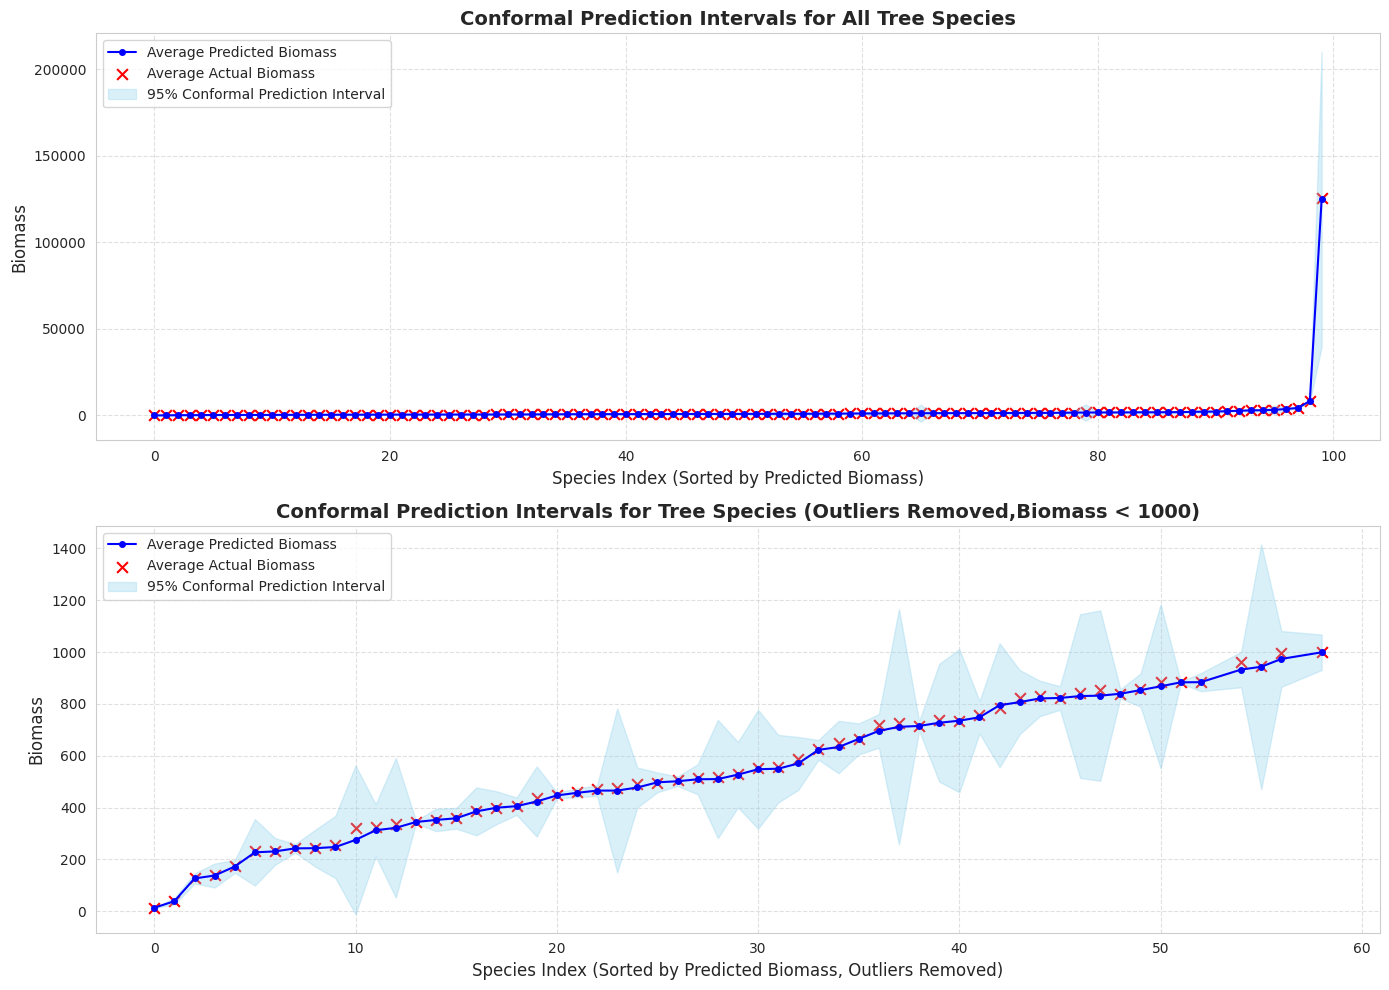

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(14, 10))
ax[0].plot(average_prediction_intervals_df_sorted.index, average_prediction_intervals_df_sorted['Average Predicted Biomass'],
         label='Average Predicted Biomass', color='blue', marker='o', linestyle='-', markersize=4, linewidth=1.5)
ax[0].scatter(average_prediction_intervals_df_sorted.index, average_prediction_intervals_df_sorted['Average Actual Biomass'],
            label='Average Actual Biomass', color='red', marker='x', s=60)
ax[0].fill_between(average_prediction_intervals_df_sorted.index,
                 average_prediction_intervals_df_sorted['Average Lower Bound'],
                 average_prediction_intervals_df_sorted['Average Upper Bound'],
                 color='skyblue', alpha=0.3, label='95% Conformal Prediction Interval')

ax[0].set_xlabel('Species Index (Sorted by Predicted Biomass)', fontsize=12)
ax[0].set_ylabel('Biomass', fontsize=12)
ax[0].set_title('Conformal Prediction Intervals for All Tree Species', fontsize=14, fontweight='bold')
ax[0].legend(fontsize=10)
ax[0].grid(True, linestyle='--', alpha=0.6)

ax[1].plot(filtered_prediction_intervals_df.index, filtered_prediction_intervals_df['Average Predicted Biomass'],
         label='Average Predicted Biomass', color='blue', marker='o', linestyle='-', markersize=4, linewidth=1.5)
ax[1].scatter(filtered_prediction_intervals_df.index, filtered_prediction_intervals_df['Average Actual Biomass'],
            label='Average Actual Biomass', color='red', marker='x', s=60)
ax[1].fill_between(filtered_prediction_intervals_df.index,
                 filtered_prediction_intervals_df['Average Lower Bound'],
                 filtered_prediction_intervals_df['Average Upper Bound'],
                 color='skyblue', alpha=0.3, label='95% Conformal Prediction Interval')
ax[1].set_xlabel('Species Index (Sorted by Predicted Biomass, Outliers Removed)', fontsize=12)
ax[1].set_ylabel('Biomass', fontsize=12)
ax[1].set_title('Conformal Prediction Intervals for Tree Species (Outliers Removed,Biomass < 1000)', fontsize=14, fontweight='bold')
ax[1].legend(fontsize=10)
ax[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
x_conf_train_test = train[['DO_BH', 'HT_TOT', 'VOLUME']]
y_conf_train_test = train['TT_DW_CRM']
X = df_volume[['DO_BH', 'HT_TOT', 'VOLUME']]
X.head()

,DO_BH,HT_TOT,VOLUME
0,7.5,45.2,1996.873144
1,9.3,62.7,4259.150167
2,9.7,56.7,4190.019479
3,11.4,66.1,6746.844127
4,6.4,51.8,1666.399867


In [ ]:
quantile_lower = alpha / 2
quantile_upper = 1 - alpha / 2

def quantile_knn_predict(X_train_df, y_train_series, X_test_df, k, quantile):
  X_train = X_train_df.values
  X_test = X_test_df.values
  predictions = []
  for x_test_row in X_test:
    distances = np.sqrt(np.sum((X_train - x_test_row)**2, axis=1))
    k_indices = np.argsort(distances)[:k]
    k_neighbors_y = y_train_series.iloc[k_indices]
    pred = np.quantile(k_neighbors_y, quantile)
    predictions.append(pred)
  return np.array(predictions)

y_pred_lower_quantile = quantile_knn_predict(x_conf_train_test, y_conf_train_test, X, 3, quantile_lower)
y_pred_upper_quantile = quantile_knn_predict(x_conf_train_test, y_conf_train_test, X, 3, quantile_upper)

pi_lower_quantile = y_pred_lower_quantile
pi_upper_quantile = y_pred_upper_quantile

print(f"kNN Quantile Regression (k={k}):")
print(f"Lower quantile (τ={quantile_lower}): {np.mean(y_pred_lower_quantile):.4f}")
print(f"Upper quantile (τ={quantile_upper}): {np.mean(y_pred_upper_quantile):.4f}")
print(f"Average prediction interval width: {np.mean(pi_upper_quantile - pi_lower_quantile):.4f}")

y_pred_lower_cal = quantile_knn_predict(x_conf_train_test, y_conf_train_test, X_cal, 3, quantile_lower)
y_pred_upper_cal = quantile_knn_predict(x_conf_train_test, y_conf_train_test, X_cal, 3, quantile_upper)
coverage_quantile = np.mean((y_cal >= y_pred_lower_cal) & (y_cal <= y_pred_upper_cal))
print(f"Coverage on calibration set: {coverage_quantile*100:.1f}% (target: 95%, but no guarantee)")

kNN Quantile Regression (k=3):
Lower quantile (τ=0.025): 715.9160
Upper quantile (τ=0.975): 777.4005
Average prediction interval width: 61.4845
Coverage on calibration set: 54.5% (target: 95%, but no guarantee)


In [ ]:
plot_data = {
    'COMMON_NAME': df_volume['COMMON_NAME'],
    'Actual Biomass': y,
    'Predicted Biomass': y_pred_knn,
    'Lower Quantile': pi_lower_quantile,
    'Upper Quantile': pi_upper_quantile
}
plot_df_quantile = pd.DataFrame(plot_data)
plot_df_quantile.head()

DataFrame 'plot_df_quantile' created successfully.


,COMMON_NAME,Actual Biomass,Predicted Biomass,Lower Quantile,Upper Quantile
0,balsam fir,178.86,288.376667,280.5235,302.5255
1,balsam fir,323.46,569.980000,556.7980,579.7025
2,balsam fir,342.47,554.743333,535.3700,573.1420
3,balsam fir,499.35,883.920000,805.3595,997.9340
4,balsam fir,113.92,227.920000,224.4210,234.2155


In [ ]:
average_quantile_prediction_intervals_df = plot_df_quantile.groupby('COMMON_NAME').mean().reset_index()
average_quantile_prediction_intervals_df.columns = [
    'Species Name',
    'Average Actual Biomass',
    'Average Predicted Biomass',
    'Average Lower Quantile',
    'Average Upper Quantile'
]
average_quantile_prediction_intervals_df.head()

Averaged DataFrame created successfully.


,Species Name,Average Actual Biomass,Average Predicted Biomass,Average Lower Quantile,Average Upper Quantile
0,Alaska yellow-cedar,1873.095583,991.001865,965.040650,1018.210922
1,American basswood,821.535827,902.023562,868.258523,936.139528
2,American beech,1867.457333,1067.224643,1026.632668,1108.284710
3,American elm,515.399755,604.992536,573.901236,639.266190
4,American holly,242.321132,241.207987,231.467363,250.994613


In [ ]:
average_quantile_prediction_intervals_df_sorted_almost = average_quantile_prediction_intervals_df.sort_values(by='Average Predicted Biomass').reset_index(drop=True)
average_quantile_prediction_intervals_df_sorted = average_quantile_prediction_intervals_df_sorted_almost.loc[average_quantile_prediction_intervals_df_sorted_almost['Average Actual Biomass']<=1000]
average_quantile_prediction_intervals_df_sorted.head()

DataFrame sorted by 'Average Predicted Biomass'.


,Species Name,Average Actual Biomass,Average Predicted Biomass,Average Lower Quantile,Average Upper Quantile
0,flowering dogwood,40.332432,41.149666,37.746020,44.701868
1,black cottonwood,13.399638,42.060559,37.371224,47.296942
2,oak spp.,127.829568,120.845504,113.721873,128.289252
3,Other or unknown live tree,172.847068,194.710143,183.018078,206.501581
4,black spruce,141.501392,210.715616,198.498823,223.046458


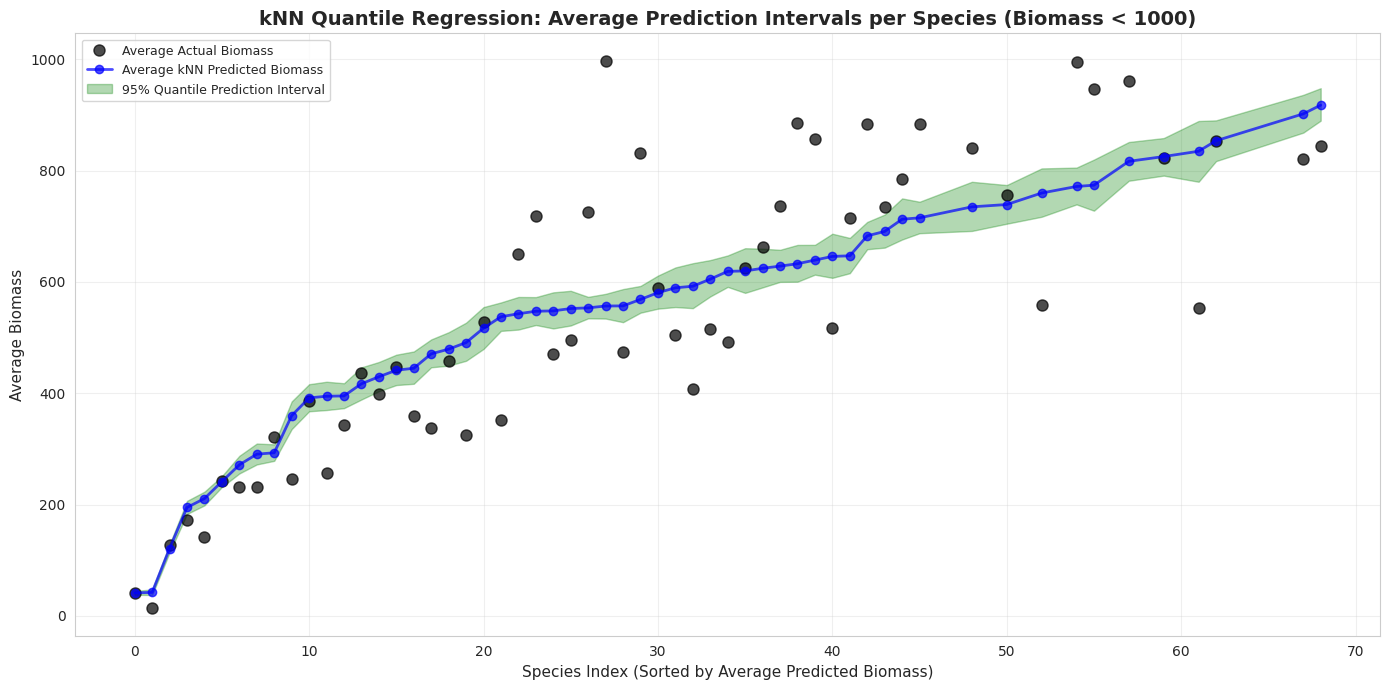

Visualization of average quantile prediction intervals generated successfully.


In [ ]:
plt.figure(figsize=(14, 7))

sort_idx = np.argsort(average_quantile_prediction_intervals_df_sorted['Species Name'])

plt.plot(average_quantile_prediction_intervals_df_sorted.index, average_quantile_prediction_intervals_df_sorted['Average Actual Biomass'], 'o', label='Average Actual Biomass', markersize=8, color='black', alpha=0.7)
plt.plot(average_quantile_prediction_intervals_df_sorted.index, average_quantile_prediction_intervals_df_sorted['Average Predicted Biomass'], 'o-', label='Average kNN Predicted Biomass', linewidth=2, markersize=6, color='blue', alpha=0.7)
plt.fill_between(average_quantile_prediction_intervals_df_sorted.index,
                 average_quantile_prediction_intervals_df_sorted['Average Lower Quantile'],
                 average_quantile_prediction_intervals_df_sorted['Average Upper Quantile'],
                 alpha=0.3, label='95% Quantile Prediction Interval', color='green')

plt.xlabel('Species Index', fontsize=11)
plt.ylabel('Average Biomass', fontsize=11)
plt.title('kNN Quantile Regression: Average Prediction Intervals per Species (Biomass < 1000)', fontsize=14, fontweight='bold')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Visualization of average quantile prediction intervals generated successfully.")

In [ ]:
all_species_cqr_results = []
alpha = 0.05
k = 3

for tree_name in unique_species:
    tree_subset = df_volume[df_volume['COMMON_NAME'] == tree_name].copy()

    train_split_ratio = 0.8
    cal_split_ratio = 0.10

    train_size = int(len(tree_subset) * train_split_ratio)
    cal_size = int(len(tree_subset) * cal_split_ratio)

    train_species = tree_subset.iloc[:train_size]
    calibration_species = tree_subset.iloc[train_size : train_size + cal_size]

    features = ['DO_BH', 'HT_TOT', 'VOLUME']
    target = 'TT_DW_CRM'

    X_train_species = train_species[features]
    y_train_species = train_species[target]
    X_calibration_species = calibration_species[features]
    y_calibration_species = calibration_species[target]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_species)
    X_calibration_scaled = scaler.transform(X_calibration_species)
    X_full_species_scaled = scaler.transform(tree_subset[features])

    X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=features)
    X_calibration_scaled_df = pd.DataFrame(X_calibration_scaled, columns=features)
    X_full_species_scaled_df = pd.DataFrame(X_full_species_scaled, columns=features)

    q_lower_cal_base = quantile_knn_predict(X_train_scaled_df, y_train_species,
                                            X_calibration_scaled_df, k, alpha / 2)
    q_upper_cal_base = quantile_knn_predict(X_train_scaled_df, y_train_species,
                                            X_calibration_scaled_df, k, 1 - alpha / 2)

    non_conformity_scores_cal = np.maximum(q_lower_cal_base - y_calibration_species.values,
                                           y_calibration_species.values - q_upper_cal_base)
    non_conformity_scores_cal[non_conformity_scores_cal < 0] = 0

    q_conformal_cqr = np.quantile(non_conformity_scores_cal, 1 - alpha)

    q_lower_full_base = quantile_knn_predict(X_train_scaled_df, y_train_species, X_full_species_scaled_df, k, alpha / 2)
    q_upper_full_base = quantile_knn_predict(X_train_scaled_df, y_train_species, X_full_species_scaled_df, k, 1 - alpha / 2)

    pi_lower_cqr = q_lower_full_base - q_conformal_cqr
    pi_upper_cqr = q_upper_full_base + q_conformal_cqr

    y_pred_median_full = quantile_knn_predict(X_train_scaled_df, y_train_species, X_full_species_scaled_df, k, 0.5)

    avg_actual = tree_subset[target].mean()
    avg_predicted = y_pred_median_full.mean()
    avg_lower_bound = pi_lower_cqr.mean()
    avg_upper_bound = pi_upper_cqr.mean()

    species_results = {
        'tree_name': tree_name,
        'average_actual_biomass': avg_actual,
        'average_predicted_biomass': avg_predicted,
        'average_lower_bound_cqr': avg_lower_bound,
        'average_upper_bound_cqr': avg_upper_bound
    }
    all_species_cqr_results.append(species_results)

print("Conformalized Quantile Regression prediction intervals calculated for all species.")

Conformalized Quantile Regression prediction intervals calculated for all species.


In [ ]:
cqr_prediction_intervals_df = pd.DataFrame(all_species_cqr_results)
cqr_prediction_intervals_df.columns = [
    'Species Name',
    'Average Actual Biomass',
    'Average Predicted Biomass',
    'Average Lower Bound CQR',
    'Average Upper Bound CQR'
]

cqr_prediction_intervals_df_sorted = cqr_prediction_intervals_df.sort_values(by='Average Predicted Biomass').reset_index(drop=True)
cqr_prediction_intervals_df_filtered = cqr_prediction_intervals_df_sorted[cqr_prediction_intervals_df_sorted['Average Actual Biomass'] <= 1000]

print("Average Conformalized Quantile Regression (CQR) prediction intervals per species:")
display(cqr_prediction_intervals_df_filtered.head())

Average Conformalized Quantile Regression (CQR) prediction intervals per species:


,Species Name,Average Actual Biomass,Average Predicted Biomass,Average Lower Bound CQR,Average Upper Bound CQR
0,black cottonwood,13.399638,13.366283,12.227439,14.292095
1,flowering dogwood,40.332432,38.697812,29.568861,48.038736
2,oak spp.,127.829568,126.643308,110.259301,142.438528
3,black spruce,141.501392,137.702192,89.238177,186.326719
4,Other or unknown live tree,172.847068,171.024881,151.483529,194.638210


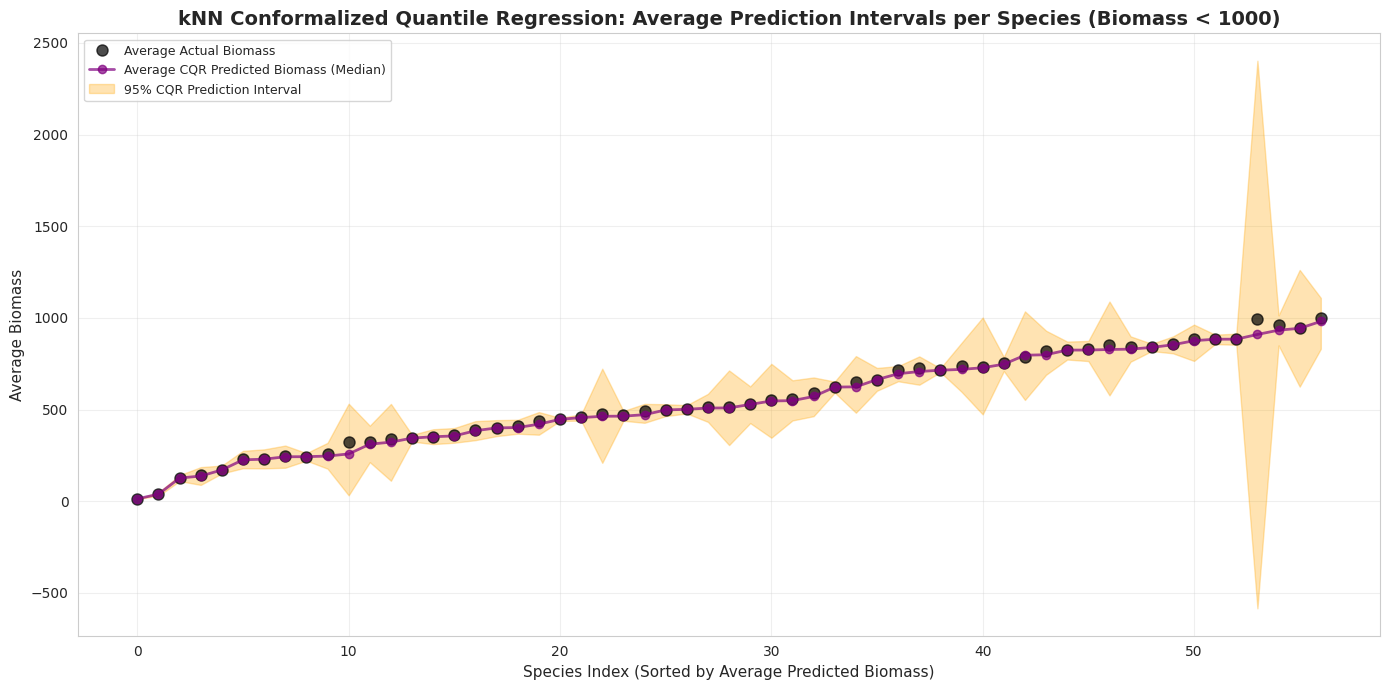

Visualization of average CQR prediction intervals generated successfully.


In [ ]:
plt.figure(figsize=(14, 7))

plt.plot(cqr_prediction_intervals_df_filtered.index, cqr_prediction_intervals_df_filtered['Average Actual Biomass'], 'o', label='Average Actual Biomass', markersize=8, color='black', alpha=0.7)
plt.plot(cqr_prediction_intervals_df_filtered.index, cqr_prediction_intervals_df_filtered['Average Predicted Biomass'], 'o-', label='Average CQR Predicted Biomass (Median)', linewidth=2, markersize=6, color='purple', alpha=0.7)
plt.fill_between(cqr_prediction_intervals_df_filtered.index,
                 cqr_prediction_intervals_df_filtered['Average Lower Bound CQR'],
                 cqr_prediction_intervals_df_filtered['Average Upper Bound CQR'],
                 alpha=0.3, label='95% CQR Prediction Interval', color='orange')

plt.xlabel('Species Index (Sorted by Average Predicted Biomass)', fontsize=11)
plt.ylabel('Average Biomass', fontsize=11)
plt.title('kNN Conformalized Quantile Regression: Average Prediction Intervals per Species (Biomass < 1000)', fontsize=14, fontweight='bold')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Visualization of average CQR prediction intervals generated successfully.")